# Phase A & B Validation: TravelGraph & Temporal Simulation
This notebook provides visual validations for the core architectural components of the Jeepney Routing System:
1. **Three-Layer Graph Architecture**: Renders individual projections of the six edge transitions (SW, WA, RI, AL, EW, TR) that bridge pedestrian streets and jeepney routes.
2. **Sample Journey**: Finds a shortest journey requiring a route-to-route transfer and visualizes it along the 3D travel graph.
3. **Temporal Simulation Visualizer**: Runs the simulation step-by-step and maps active jeepneys and passengers (waiting and riding) across ticks, validating the physics of agent boarding and route progression.

In [1]:
import os
import random
import yaml
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

from utils_simplified import (
    reuse_citygraph,
    reuse_ddm,
    generate_route_system,
    generate_dummy_yaml,
    build_travelgraph,
    run_simulation_env,
    SimEnvironment
)
from utils.jeep import Jeep
from utils.jeep_system import JeepSystem
from utils.travel_graph_3d_vis import TravelGraph3DVisualizer

# Load the pre-compiled static environment data
cg = reuse_citygraph("results_and_discussion/pkl/profile_p1.pkl")
ddm = reuse_ddm("results_and_discussion/pkl/ddm_8am.pkl")

# Generate 20 routes for mapping
routes = generate_route_system(2, cg, ddm)
print("Environment successfully loaded.")

[INFO] Reusing CityGraph from pickle file: results_and_discussion/pkl/profile_p1.pkl
[INFO] Reusing DirectDemandSampler from pickle file: results_and_discussion/pkl/ddm_8am.pkl
[INFO] Generating 2 routes...
Environment successfully loaded.


### TravelGraph Construction
We build a dummy configuration profile and construct a 3-layer `TravelGraph` that combines walkable city paths with our route system configurations.

In [2]:
yaml_path = "configs/dummy_nb1.yaml"
generate_dummy_yaml(yaml_path, **{
    "simulation.num_ticks": 200,
    "simulation.total_allocatable_jeeps": 25,
    "cg_pkl": "results_and_discussion/pkl/profile_p1.pkl",
    "ddm_pkl": "results_and_discussion/pkl/ddm_8am.pkl",
    "travel_graph.transfer_wt": 15.0,
})

tg = build_travelgraph(cg, yaml_path, routes)
print(f"TravelGraph built: {len(tg.travel_graph)} transitions.")

[INFO] Generating dummy YAML at configs/dummy_nb1.yaml with overrides: {'simulation.num_ticks': 200, 'simulation.total_allocatable_jeeps': 25, 'cg_pkl': 'results_and_discussion/pkl/profile_p1.pkl', 'ddm_pkl': 'results_and_discussion/pkl/ddm_8am.pkl', 'travel_graph.transfer_wt': 15.0}
[INFO] Building TravelGraph using config from: configs/dummy_nb1.yaml
TravelGraph built: 201419 transitions.


## 1. Three-Layer Graph Visualizations (Six Illustrations)
We use the 3D travel graph visualizer to render projections of the six individual transition edge types:
*   **SW (Start Walk)**: Red edges connecting Layer 1 (walking network) to Layer 2 (stop/boarding gate).
*   **WA (Wait)**: Orange edges representing waiting time penalty inside Layer 2.
*   **RI (Ride)**: Yellow edges representing vehicle movement along jeepney routes in Layer 3.
*   **AL (Alight)**: Green edges connecting Layer 3 back down to Layer 1 (alighting stop).
*   **EW (End Walk)**: Blue edges connecting Layer 1 stop coordinates to destination locations.
*   **TR (Transfer)**: Teal edges connecting Layer 3 Stop Node of one route to Layer 2 Wait Node of another route (representing passenger transfer).


--- Rendering Start Walk (SW) - Layer 1 (Walk) to Layer 2 (Wait) ---


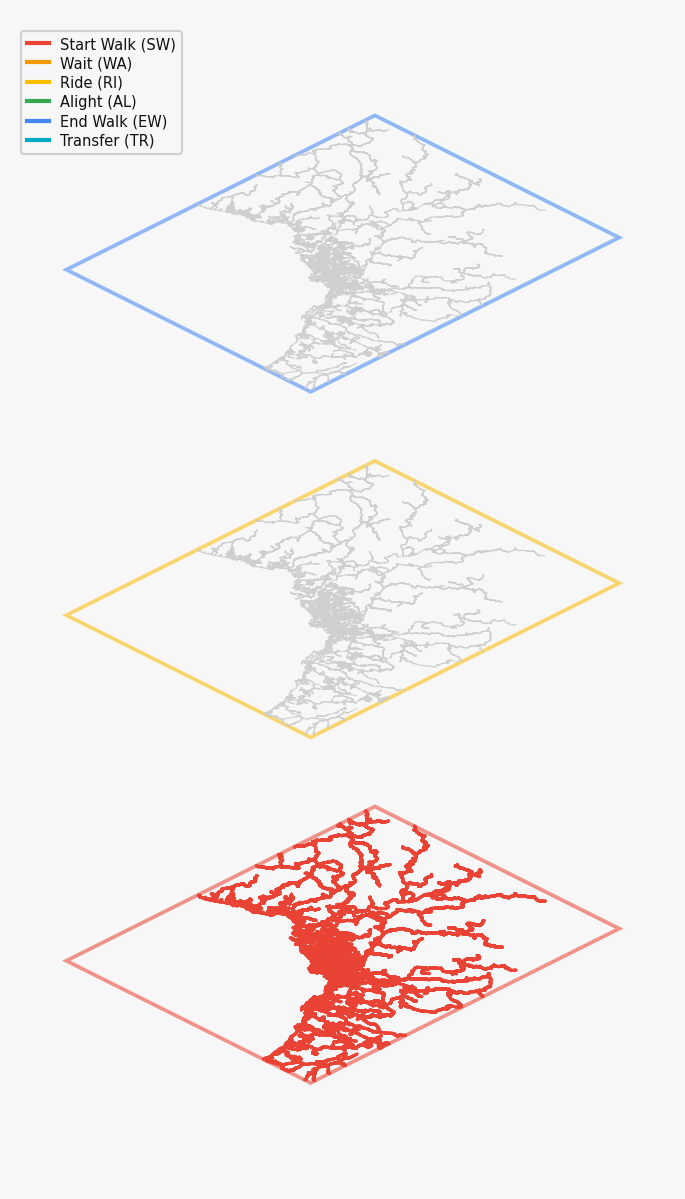


--- Rendering Wait (WA) - Layer 2 (Wait) to Layer 3 (Ride) ---


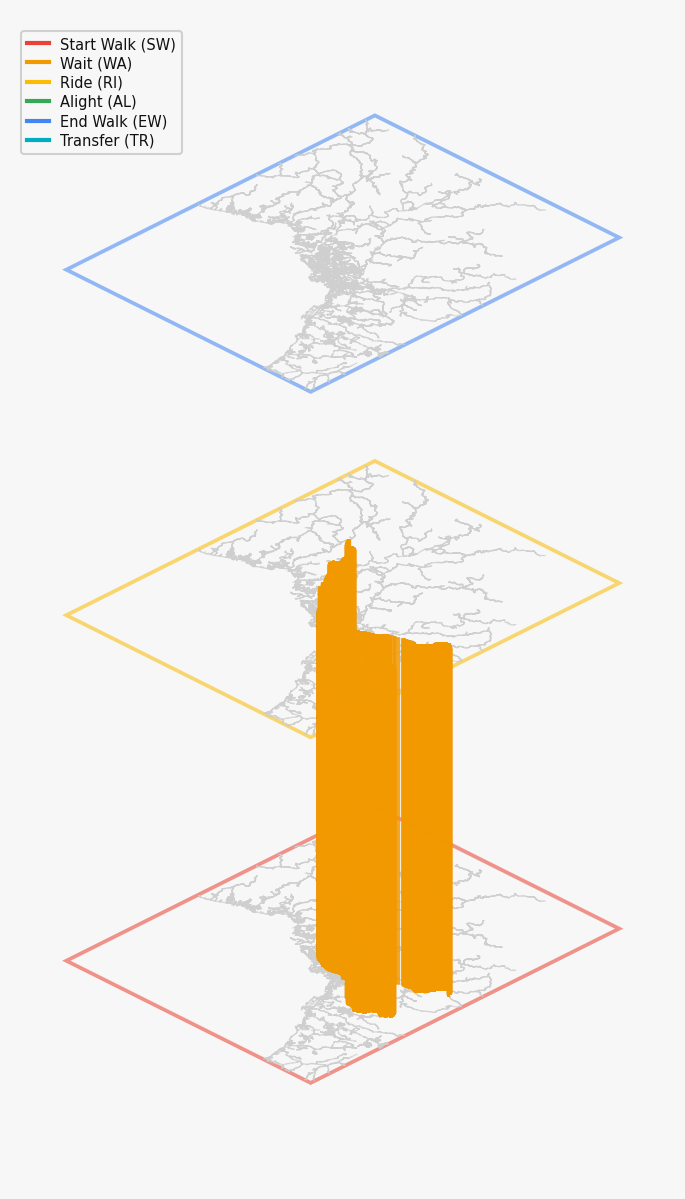


--- Rendering Ride (RI) - Layer 3 (Ride) Transit Edges ---


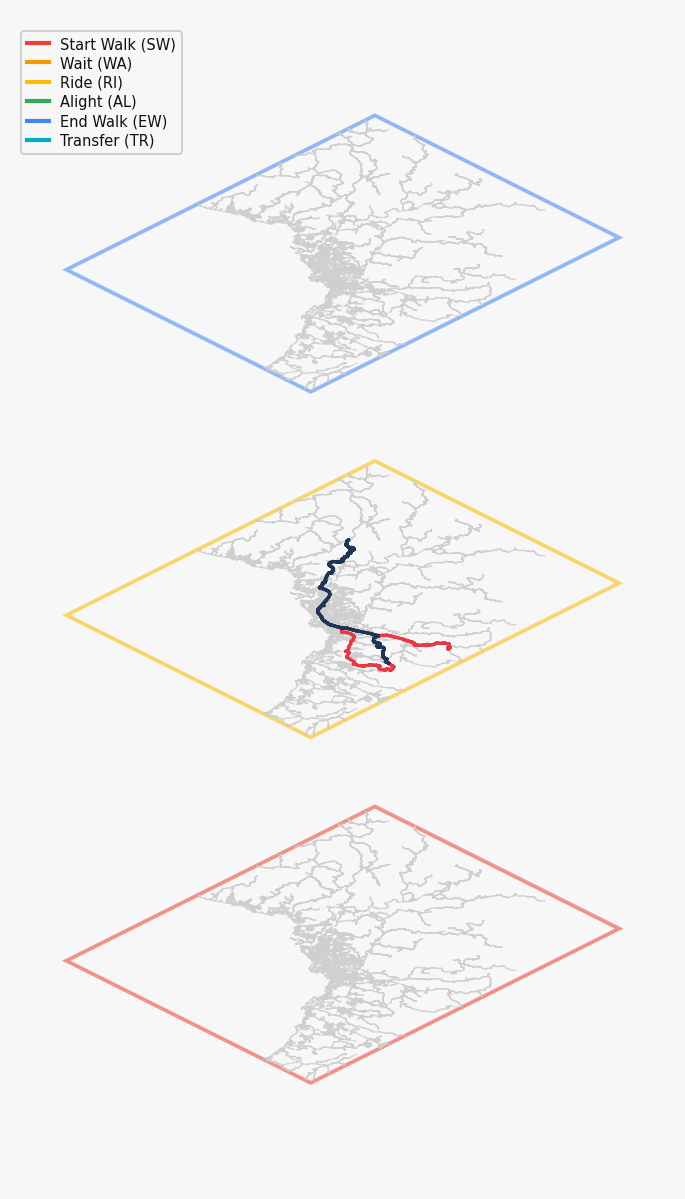


--- Rendering Alight (AL) - Layer 3 (Ride) to Layer 1 (Walk) ---


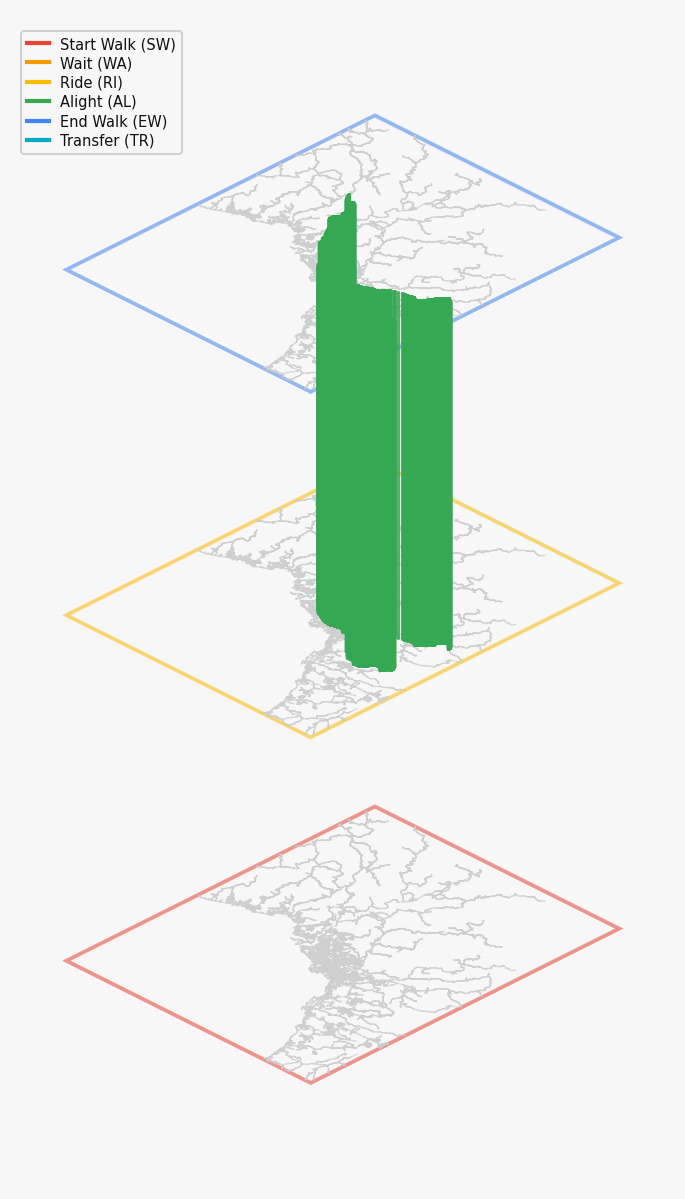


--- Rendering End Walk (EW) - Layer 1 Stop to Layer 1 Destination ---


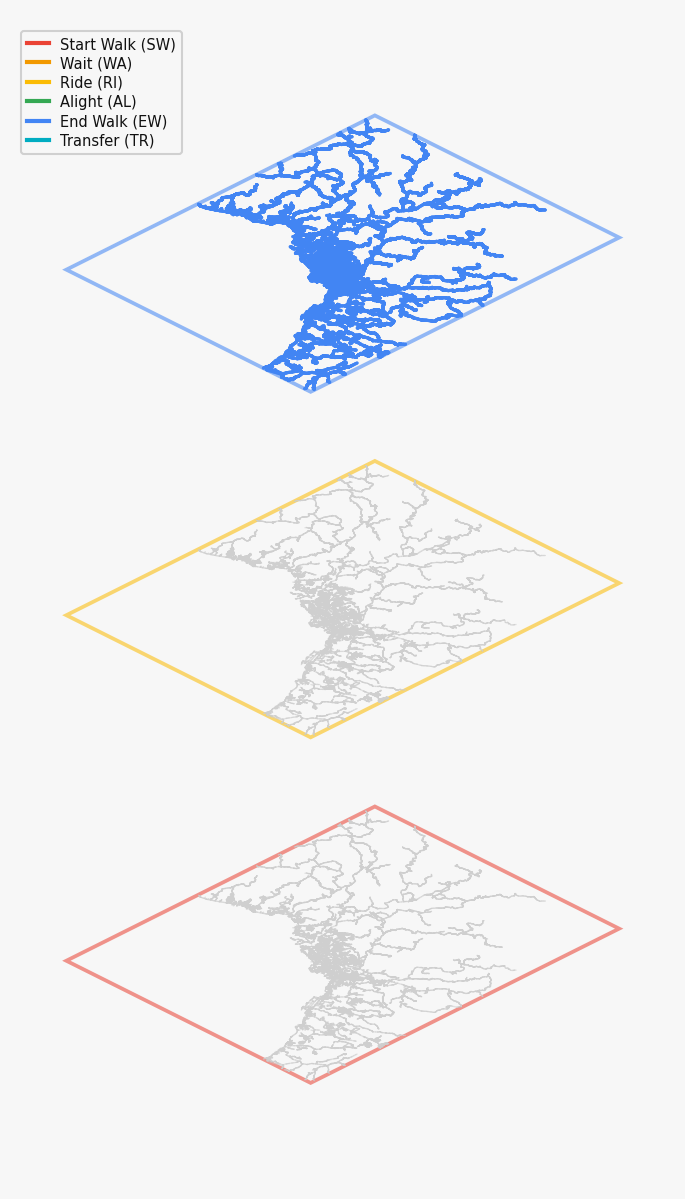


--- Rendering Transfer (TR) - Layer 3 to Layer 2 stop of another route ---


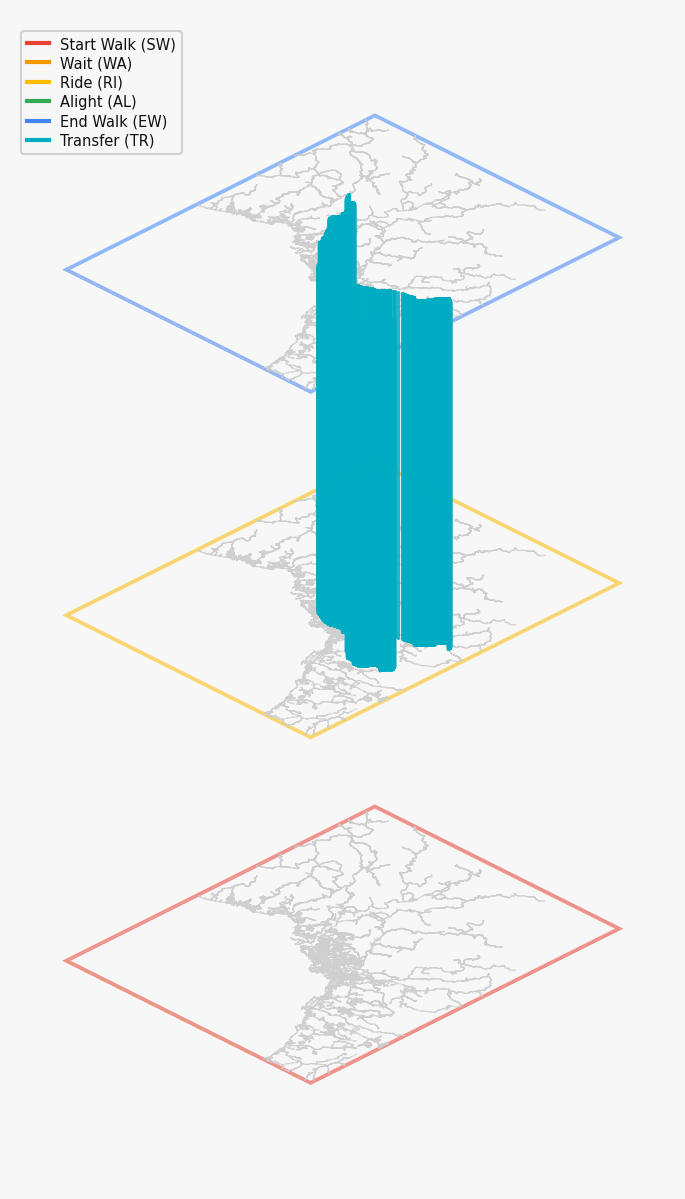

In [3]:
# highlight_edges=[] — no journey path to overlay; passing tg.travel_graph here
# caused the entire graph to be re-drawn at journey_thickness on top of itself (Bug 1 & 2).
visualizer = TravelGraph3DVisualizer(tg.travel_graph, highlight_edges=[], mode="light_nolabels", edge_thickness=1.5, journey_thickness=3.0, node_radius=20)

edge_types = [
    ("SW", "Start Walk (SW) - Layer 1 (Walk) to Layer 2 (Wait)"),
    ("WA", "Wait (WA) - Layer 2 (Wait) to Layer 3 (Ride)"),
    ("RI", "Ride (RI) - Layer 3 (Ride) Transit Edges"),
    ("AL", "Alight (AL) - Layer 3 (Ride) to Layer 1 (Walk)"),
    ("EW", "End Walk (EW) - Layer 1 Stop to Layer 1 Destination"),
    ("TR", "Transfer (TR) - Layer 3 to Layer 2 stop of another route"),
]

os.makedirs("results_and_discussion/images", exist_ok=True)

for prefix, name in edge_types:
    print(f"\n--- Rendering {name} ---")
    img = visualizer.draw(
        display_walk=(prefix == "SW"),
        display_wait=(prefix == "WA"),
        display_ride=(prefix == "RI"),
        display_alight=(prefix == "AL"),
        display_end_walk=(prefix == "EW"),
        display_transfer=(prefix == "TR"),
        display_direct=False,
        legend_on=True  # Bug 3 fix: was False, suppressing the legend
    )
    img.save(f"results_and_discussion/images/layer_transition_{prefix}.png")
    display(img)

## 2. Sample Journey (Featuring a Transfer)
We stochastically search for a passenger travel journey that involves a transfer between two jeepney routes. Once found, we print its transition nodes and highlight it inside the 3D travel graph.

Searching for a journey containing a transfer...
Found a valid transfer journey with 1156 edge transitions!
  Segment 1: SW10259              | Cost: 0.41 EIVM
  Segment 2: SW10261              | Cost: 0.34 EIVM
  Segment 3: SW10263              | Cost: 0.73 EIVM
  Segment 4: SW10265              | Cost: 0.84 EIVM
  Segment 5: SW10267              | Cost: 1.19 EIVM
  Segment 6: SW10269              | Cost: 0.73 EIVM
  Segment 7: SW10271              | Cost: 0.61 EIVM
  Segment 8: SW10273              | Cost: 0.55 EIVM
  Segment 9: SW10275              | Cost: 0.23 EIVM
  Segment 10: SW10277              | Cost: 0.19 EIVM
  Segment 11: SW10279              | Cost: 0.24 EIVM
  Segment 12: SW10281              | Cost: 0.32 EIVM
  Segment 13: SW10283              | Cost: 0.29 EIVM
  Segment 14: SW10285              | Cost: 1.22 EIVM
  Segment 15: SW10287              | Cost: 0.70 EIVM
  Segment 16: SW10289              | Cost: 0.65 EIVM
  Segment 17: SW10291              | Cost: 0.27 EIVM


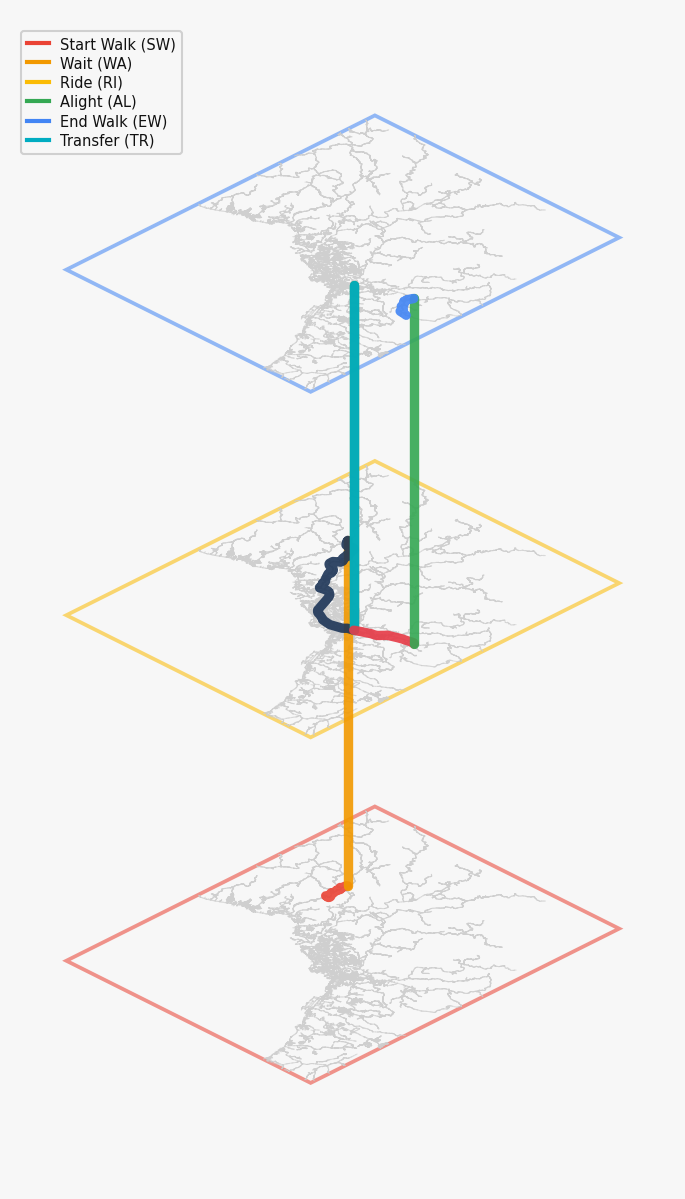

In [4]:
print("Searching for a journey containing a transfer...")
found = False
journey = []
for _ in range(500):
    start = ddm.get_point()
    end = ddm.get_point()
    if start and end and start != end:
        path = tg.findShortestJourney(start, end)
        if path and any(e.id.startswith("TR") for e in path):
            journey = path
            found = True
            break

if found:
    print(f"Found a valid transfer journey with {len(journey)} edge transitions!")
    for idx, edge in enumerate(journey):
        print(f"  Segment {idx+1}: {edge.id:<20} | Cost: {edge.weight:.2f} EIVM")
        
    journey_vis = TravelGraph3DVisualizer(tg.travel_graph, highlight_edges=journey, mode="light", edge_thickness=0.8, journey_thickness=4.5)
    img_journey = journey_vis.draw(
        display_walk=True, display_wait=True, display_ride=True, display_alight=True, display_end_walk=True, display_transfer=True, 
        display_direct=False, legend_on=True
    )
    img_journey.save("results_and_discussion/images/sample_journey_transfer.png")
    display(img_journey)
else:
    print("Could not find a transfer journey stochastically. Rendering a direct path instead.")
    start = ddm.get_point()
    end = ddm.get_point()
    path = tg.findShortestJourney(start, end)
    if path:
        journey_vis = TravelGraph3DVisualizer(tg.travel_graph, highlight_edges=path, mode="light", edge_thickness=0.8, journey_thickness=4.5)
        img_journey = journey_vis.draw(legend_on=True)
        img_journey.save("results_and_discussion/images/sample_journey_direct.png")
        display(img_journey)

## 3. Agent-Based Temporal Simulation Telemetry Snapshots
We run a manual simulation loop, spawning passenger agents stochastically and tracking vehicle movement tick-by-tick. We capture snapshots of the network state at ticks 10, 40, 80, and 120, showing waiting passengers (red circles), riding passengers (green crosses), and jeepney positions (blue triangles) moving along their route paths.

In [ ]:
import yaml
import math
from PIL import Image
import matplotlib.pyplot as plt

from utils.passenger import Passenger
from utils.simulation import Simulation


# Make sure this matches the path you used earlier in your notebook
yaml_path = "configs/dummy_nb1.yaml" 

with open(yaml_path, 'r', encoding='utf-8') as f:
    config_dict = yaml.safe_load(f)

sim = Simulation(tg, routes, config_dict, None, 5000)

# Disable the stochastic passenger generator so the system is empty
sim.passenger_generator = None 

# 2. Inject a Single Passenger (Matching your OD pair from earlier)
# Replace 'origin_node' and 'dest_node' with the exact nodes used in Section 2
single_passenger = Passenger(start=origin_node, target=dest_node)
sim.passengers.append(single_passenger)

# 3. Setup Telemetry Snapshots
snapshot_ticks = [10, 40, 80, 120]
snapshots = []

# Define your map boundaries for the draw context (adjust to your city bounds)
# context = ((top_left_lon, top_left_lat), (bottom_right_lon, bottom_right_lat))
context = ((125.50, 8.95), (125.60, 8.85)) 

# 4. Run the Simulation Loop
print(f"Tracking Single Passenger: {single_passenger.id}")

for tick in range(1, max(snapshot_ticks) + 1):
    sim.update() # Steps jeeps, handles boarding/alighting, and routing
    
    # Capture Snapshots using Native Draw Methods
    if tick in snapshot_ticks:
        # Create a blank map canvas (or load your base map image here)
        img_map = Image.new("RGBA", (800, 800), "white")
        
        # Use the native Simulation draw function which handles Jeeps, Routes, and Passengers
        sim.draw(img_map, context)
        
        # Alternatively, if you want to draw JUST the passenger to highlight them:
        # single_passenger.draw(img_map, context) 
        
        snapshots.append((tick, img_map.copy()))

# 5. Display the Telemetry Snapshots
fig, axes = plt.subplots(1, len(snapshots), figsize=(20, 5))

for ax, (tick, img) in zip(axes, snapshots):
    ax.imshow(img)
    ax.set_title(f"Tick: {tick} \nPassenger Status: {single_passenger.state.name}")
    ax.axis("off")

plt.tight_layout()
plt.show()

TypeError: Simulation.__init__() missing 2 required positional arguments: 'passenger_generator' and 'max_ticks'